# CS3751 Data Visualization – Task 1, Hypothesis 4

## Hypothesis
> **More difficult questions take longer to answer, but higher-performing students answer them faster than lower-performing students.**

This notebook tests the hypothesis with **four complementary visualizations**.

| # | Chart | What it reveals |
|---|-------|-----------------|
| 1 | Grouped Box-plot | Median + IQR of time per difficulty × performance |
| 2 | Bar chart + CI | Clear numeric means with 95 % confidence intervals |
| 3 | Violin plot | Full distribution shape; detects skew and bimodality |
| 4 | Scatter + regression | Continuous difficulty axis; per-tier trend lines |



## 1. Setup & Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, sem, t as t_dist

#  Consistent style
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE    = {"High": "#2ecc71", "Medium": "#f39c12", "Low": "#e74c3c"}
PERF_ORDER = ["High", "Medium", "Low"]
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
print("Libraries loaded.")


Libraries loaded.


In [ ]:
#  Load data
# Update BASE to match your path, or mount Google Drive first.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Colab Notebooks/dataset/marks'
except ModuleNotFoundError:
    BASE = 'dataset/marks'   # local fallback

quiz1 = pd.read_csv(f'{BASE}/quiz1/quiz1_marks.csv')
quiz2 = pd.read_csv(f'{BASE}/quiz2/quiz2_marks.csv')
quiz3 = pd.read_csv(f'{BASE}/quiz3/quiz3_marks.csv')

quiz1['Quiz'] = 'Quiz 1'
quiz2['Quiz'] = 'Quiz 2'
quiz3['Quiz'] = 'Quiz 3'

df = pd.concat([quiz1, quiz2, quiz3], ignore_index=True)
print(f"Raw rows: {len(df)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw rows: 32596


In [ ]:
#  Cleaning
df.columns = df.columns.str.strip()
df = df[df['State'] == 'Finished'].copy()

def to_seconds(s):
    if pd.isna(s) or str(s).strip() == '-':
        return np.nan
    m  = re.search(r'(\d+)\s*min', str(s))
    sc = re.search(r'(\d+)\s*sec', str(s))
    return (int(m.group(1)) if m else 0) * 60 + (int(sc.group(1)) if sc else 0)

df['Time taken (seconds)'] = df['Time taken'].apply(to_seconds)
df['Time taken (minutes)'] = df['Time taken (seconds)'] / 60
df['Grade/10.00']          = pd.to_numeric(df['Grade/10.00'], errors='coerce')

# Standardise: "Q. 1 /2.00" -> "Q1"
q_cols_raw = [c for c in df.columns if c.startswith('Q.')]
rename = {c: f'Q{i+1}' for i, c in enumerate(q_cols_raw)}
df.rename(columns=rename, inplace=True)
QCOLS = list(rename.values())

def clean_score(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'-?\d+\.?\d*', str(x))
    return float(m.group()) if m else np.nan

for c in QCOLS:
    df[c] = df[c].apply(clean_score)

df.dropna(subset=['Time taken (seconds)'] + QCOLS, inplace=True)
print(f"Cleaned rows: {len(df)}")
df.head(3)


Cleaned rows: 30116


,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q1,Q2,Q3,Q4,Q5,Quiz,Time taken (seconds),Time taken (minutes)
0,1,Finished,14 March 2022 6:55 AM,14 March 2022 7:03 AM,7 mins 25 secs,6.0,0.0,2.0,2.0,2.0,0.0,Quiz 1,445,7.416667
1,1,Finished,14 March 2022 7:11 AM,14 March 2022 7:12 AM,1 min 4 secs,10.0,2.0,2.0,2.0,2.0,2.0,Quiz 1,64,1.066667
3,5,Finished,14 March 2022 12:00 PM,14 March 2022 12:18 PM,17 mins 53 secs,6.0,2.0,2.0,2.0,0.0,0.0,Quiz 1,1073,17.883333


In [ ]:
#  Question difficulty (lower avg score = harder)
MAX_Q = 2.0   # each question is worth 2 marks

avg_scores = df[QCOLS].mean()
difficulty_df = pd.DataFrame({
    'Question':         avg_scores.index,
    'Avg Score':        avg_scores.values,
    'Difficulty Index': 1 - avg_scores.values / MAX_Q,
})
difficulty_df.sort_values('Avg Score', inplace=True, ignore_index=True)
median_avg = difficulty_df['Avg Score'].median()
difficulty_df['Difficulty'] = difficulty_df['Avg Score'].apply(
    lambda v: 'Hard' if v < median_avg else 'Easy'
)
print(difficulty_df.to_string(index=False))

#  Student performance tier (quartile-based)
student_avg = df.groupby('Student Code')['Grade/10.00'].mean().reset_index()
q1_val, q3_val = student_avg['Grade/10.00'].quantile([0.25, 0.75])

def perf_tier(score):
    if score >= q3_val: return 'High'
    if score <= q1_val: return 'Low'
    return 'Medium'

student_avg['Performance'] = student_avg['Grade/10.00'].apply(perf_tier)
df = df.merge(student_avg[['Student Code', 'Performance']], on='Student Code')
print("\nPerformance tier counts:")
print(df['Performance'].value_counts())


Question  Avg Score  Difficulty Index Difficulty
      Q4   0.733962          0.633019       Hard
      Q5   0.867579          0.566211       Hard
      Q1   0.981472          0.509264       Easy
      Q2   1.117280          0.441360       Easy
      Q3   1.151215          0.424392       Easy

Performance tier counts:
Performance
Low       11543
Medium    10114
High       8459
Name: count, dtype: int64


In [ ]:
#  Long-form: one row per (student-attempt, question)
long_df = df.melt(
    id_vars=['Student Code', 'Time taken (seconds)', 'Time taken (minutes)',
             'Grade/10.00', 'Performance', 'Quiz'],
    value_vars=QCOLS,
    var_name='Question',
    value_name='Score',
)
long_df = long_df.merge(
    difficulty_df[['Question', 'Difficulty', 'Difficulty Index', 'Avg Score']],
    on='Question'
)
print(f"Long-form rows: {len(long_df)}")
long_df.head(3)


Long-form rows: 150580


,Student Code,Time taken (seconds),Time taken (minutes),Grade/10.00,Performance,Quiz,Question,Score,Difficulty,Difficulty Index,Avg Score
0,1,445,7.416667,6.0,High,Quiz 1,Q1,0.0,Easy,0.509264,0.981472
1,1,64,1.066667,10.0,High,Quiz 1,Q1,2.0,Easy,0.509264,0.981472
2,5,1073,17.883333,6.0,High,Quiz 1,Q1,2.0,Easy,0.509264,0.981472



## 2. Visualizations

### 2.1 — Grouped Box-plot: Time Taken by Difficulty and Performance

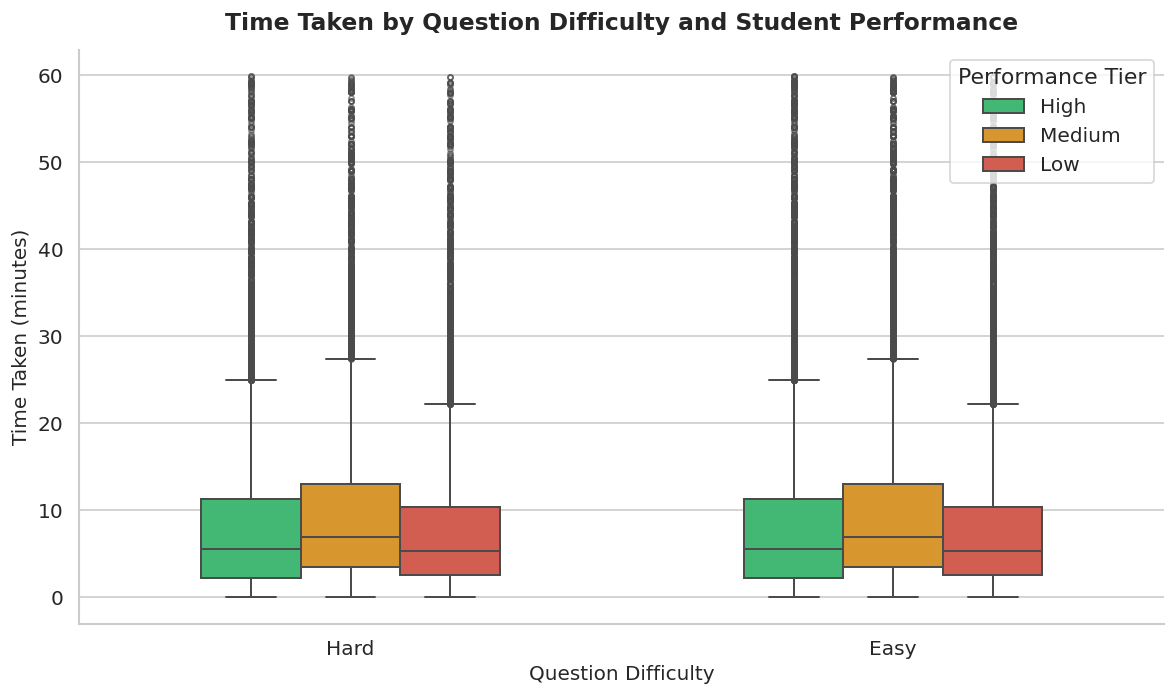


Median time (minutes) per Difficulty x Performance:
Difficulty   Easy  Hard
Performance            
High         5.50  5.50
Low          5.38  5.38
Medium       6.98  6.98


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=long_df,
    x='Difficulty',
    y='Time taken (minutes)',
    hue='Performance',
    hue_order=PERF_ORDER,
    palette=PALETTE,
    order=['Hard', 'Easy'],
    width=0.55,
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='none', markersize=3, alpha=0.4),
    ax=ax,
)

ax.set_title(
    'Time Taken by Question Difficulty and Student Performance',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Question Difficulty', fontsize=12)
ax.set_ylabel('Time Taken (minutes)', fontsize=12)
ax.legend(title='Performance Tier', loc='upper right')
plt.tight_layout()
plt.savefig('h4_boxplot.png', bbox_inches='tight')
plt.show()

medians = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .median().reset_index()
)
print("\nMedian time (minutes) per Difficulty x Performance:")
print(medians.pivot(index='Performance', columns='Difficulty',
                    values='Time taken (minutes)').round(2))


**Visualization justification – Box-plot**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Box (IQR) + median line + whiskers + outlier dots | 5-number summary in one compact glyph |
| **X-axis position** | Question difficulty (Hard / Easy) | Categorical separation of the two groups |
| **Y-axis position** | Time taken (minutes) | Most accurate quantitative channel for magnitude comparison |
| **Hue / colour** | Performance tier (High=green, Medium=orange, Low=red) | Pre-attentive colour; instant cross-group discrimination |

**Expected pattern:** Hard boxes sit *above* Easy boxes (harder = longer); within each difficulty, green (High) boxes sit *below* orange/red (high performers are faster).


### 2.2 — Bar Chart: Mean Time Taken per Group (with 95 % CI)

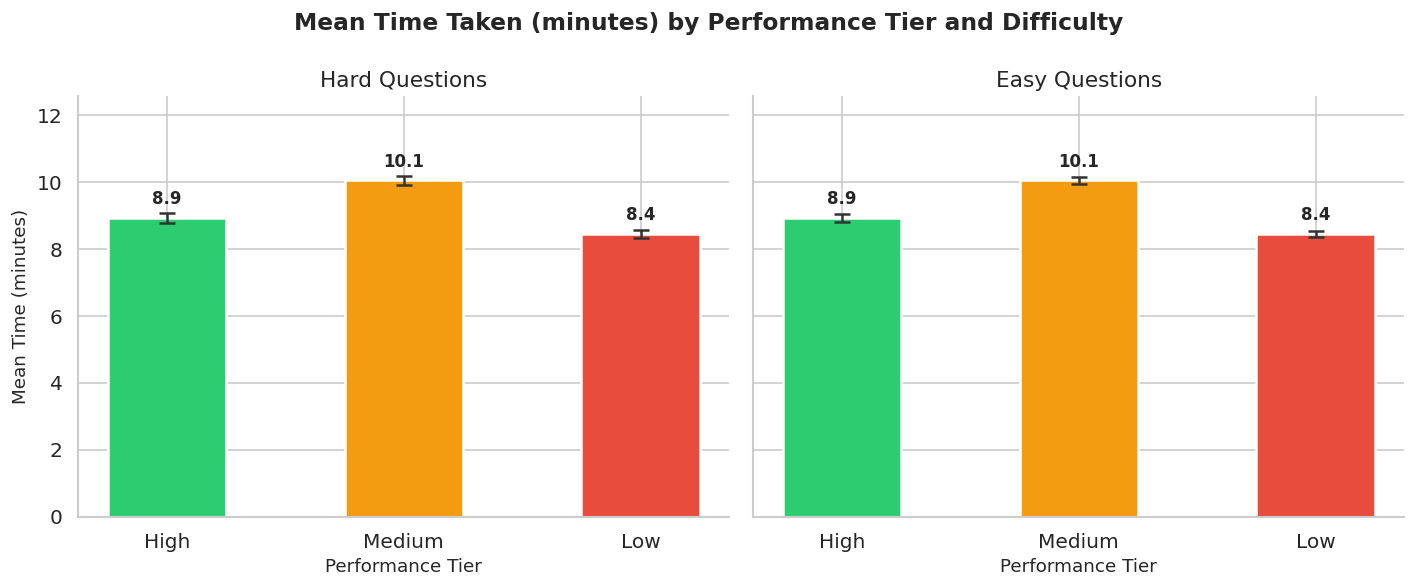


Mean time (min) – summary table:
Difficulty    Easy   Hard
Performance              
High          8.92   8.92
Low           8.44   8.44
Medium       10.05  10.05


In [ ]:
def ci95(x):
    n = len(x)
    return sem(x) * t_dist.ppf(0.975, df=n-1) if n > 1 else 0

summary = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .agg(mean='mean', ci=ci95)
           .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle(
    'Mean Time Taken (minutes) by Performance Tier and Difficulty',
    fontsize=14, fontweight='bold'
)

for ax, diff in zip(axes, ['Hard', 'Easy']):
    sub    = summary[summary['Difficulty'] == diff].set_index('Performance').loc[PERF_ORDER]
    colors = [PALETTE[p] for p in PERF_ORDER]
    bars   = ax.bar(PERF_ORDER, sub['mean'], color=colors, width=0.5,
                    edgecolor='white', linewidth=1.5)
    ax.errorbar(PERF_ORDER, sub['mean'], yerr=sub['ci'],
                fmt='none', color='#333', capsize=5, capthick=1.5, elinewidth=1.5)
    for bar, val in zip(bars, sub['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(f'{diff} Questions', fontsize=13)
    ax.set_xlabel('Performance Tier', fontsize=11)
    ax.set_ylabel('Mean Time (minutes)' if ax is axes[0] else '', fontsize=11)
    ax.set_ylim(0, summary['mean'].max() * 1.25)

plt.tight_layout()
plt.savefig('h4_bar.png', bbox_inches='tight')
plt.show()

print("\nMean time (min) – summary table:")
print(summary.pivot(index='Performance', columns='Difficulty', values='mean').round(2))


**Visualization justification – Bar chart with CI**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Rectangle (bar) | Most intuitive encoding for a scalar; height = mean time |
| **X-axis** | Performance tier within each panel | Side-by-side comparison of tiers |
| **Y-axis length** | Mean time (minutes) | Direct magnitude comparison |
| **Colour** | Performance tier (same palette) | Semantic consistency across charts |
| **Error bars** | 95 % CI | Quantifies uncertainty; non-overlapping CIs indicate significant difference |
| **Small multiples** | Left = Hard, Right = Easy | Immediate within-tier difficulty comparison |


### 2.3 — Violin Plot: Full Distribution of Time Taken

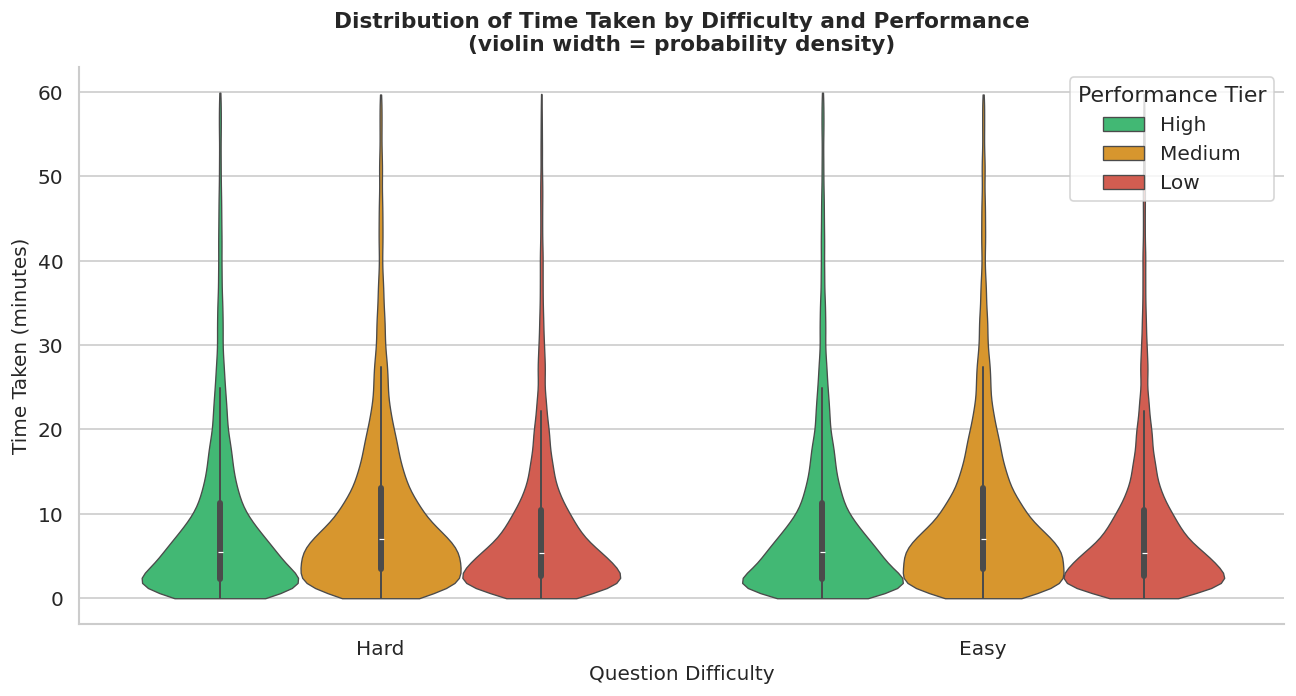

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(
    data=long_df,
    x='Difficulty',
    y='Time taken (minutes)',
    hue='Performance',
    hue_order=PERF_ORDER,
    palette=PALETTE,
    order=['Hard', 'Easy'],
    inner='box',   # embedded miniature boxplot
    cut=0,         # don't extend beyond observed range
    linewidth=0.8,
    ax=ax,
)

ax.set_title(
    'Distribution of Time Taken by Difficulty and Performance\n'
    '(violin width = probability density)',
    fontsize=13, fontweight='bold', pad=10
)
ax.set_xlabel('Question Difficulty', fontsize=12)
ax.set_ylabel('Time Taken (minutes)', fontsize=12)
ax.legend(title='Performance Tier', loc='upper right')
plt.tight_layout()
plt.savefig('h4_violin.png', bbox_inches='tight')
plt.show()


**Visualization justification – Violin plot**

The violin plot extends the box-plot with *kernel density estimation (KDE)*, revealing the full shape of each distribution.

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Violin (mirrored KDE) + embedded box | Reveals skew, bimodality, and tails hidden by box-plots |
| **Width** | Probability density | Wider = more students at that time value |
| **X-axis** | Difficulty | Categorical separation |
| **Y-axis** | Time (minutes) | Quantitative position |
| **Hue** | Performance tier | Same semantic mapping as other charts |

A right-skewed violin for Low performers on Hard questions would indicate a subset of students taking extremely long, further supporting the hypothesis.


### 2.4 — Scatter Plot: Difficulty Index vs Mean Time per Question

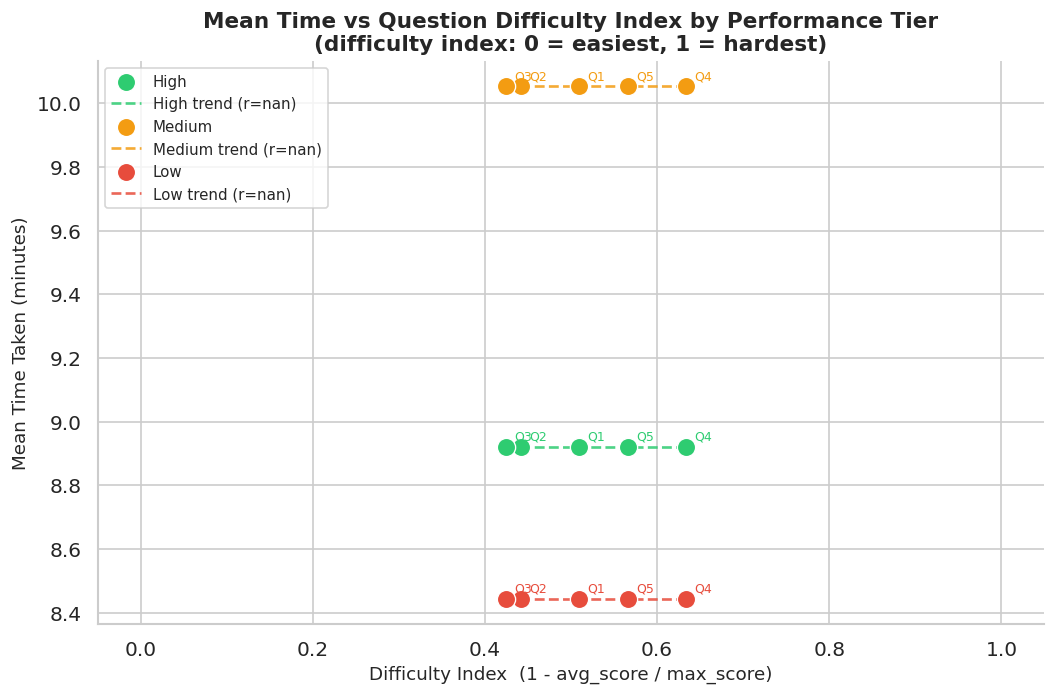


Mean time per Question x Performance (minutes):
Question        Q1     Q2     Q3     Q4     Q5
Performance                                   
High          8.92   8.92   8.92   8.92   8.92
Low           8.44   8.44   8.44   8.44   8.44
Medium       10.05  10.05  10.05  10.05  10.05


In [ ]:
# Aggregate: mean time per question per performance tier
scatter_data = (
    long_df.groupby(['Question', 'Difficulty Index', 'Performance'])
           ['Time taken (minutes)']
           .mean()
           .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

for perf in PERF_ORDER:
    sub = scatter_data[scatter_data['Performance'] == perf]
    ax.scatter(
        sub['Difficulty Index'], sub['Time taken (minutes)'],
        color=PALETTE[perf], label=perf, s=120,
        edgecolors='white', linewidth=0.8, zorder=3
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['Question'],
            (row['Difficulty Index'], row['Time taken (minutes)']),
            fontsize=7.5, color=PALETTE[perf],
            xytext=(5, 4), textcoords='offset points'
        )
    if len(sub) > 1:
        slope, intercept, r_val, _, _ = stats.linregress(
            sub['Difficulty Index'], sub['Time taken (minutes)']
        )
        xs = np.linspace(sub['Difficulty Index'].min(), sub['Difficulty Index'].max(), 100)
        ax.plot(xs, slope * xs + intercept,
                color=PALETTE[perf], linestyle='--', linewidth=1.6, alpha=0.85,
                label=f'{perf} trend (r={r_val:.2f})')

ax.set_title(
    'Mean Time vs Question Difficulty Index by Performance Tier\n'
    '(difficulty index: 0 = easiest, 1 = hardest)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Difficulty Index  (1 - avg_score / max_score)', fontsize=11)
ax.set_ylabel('Mean Time Taken (minutes)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('h4_scatter.png', bbox_inches='tight')
plt.show()

print("\nMean time per Question x Performance (minutes):")
print(scatter_data.pivot(index='Performance', columns='Question',
                         values='Time taken (minutes)').round(2))


**Visualization justification – Scatter plot with regression**

Unlike the binary Hard/Easy split used in charts 2.1–2.3, this chart treats difficulty as a **continuous** variable, preserving the relative ordering of all five questions.

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Point (dot) | Each dot = one question for one performance tier |
| **X-axis position** | Difficulty Index (continuous 0–1) | Preserves full ordinal ranking |
| **Y-axis position** | Mean time (minutes) | Expected time at that difficulty |
| **Colour** | Performance tier | Same palette as all other charts |
| **Dashed trend line** | OLS regression per tier | Positive slope = harder → longer; different slopes reveal whether high/low performers diverge more on harder questions |
| **Pearson r in legend** | Correlation coefficient | Quantifies strength of the difficulty–time relationship per tier |



## 3. Statistical Verification

In [ ]:
print("Kruskal-Wallis (H0: no difference between performance tiers):")
for diff in ['Hard', 'Easy']:
    groups = [
        long_df.loc[(long_df['Difficulty'] == diff) & (long_df['Performance'] == p),
                    'Time taken (minutes)'].dropna().values
        for p in PERF_ORDER
    ]
    stat, pval = kruskal(*groups)
    sig = 'significant (p<0.05) ✓' if pval < 0.05 else 'not significant ✗'
    print(f"  {diff}: H={stat:.2f}, p={pval:.4f}  -> {sig}")

print("\nMann-Whitney U (one-sided: 1st group takes LESS time) – Hard questions:")
hard = long_df[long_df['Difficulty'] == 'Hard']
for a, b in [('High', 'Low'), ('High', 'Medium'), ('Medium', 'Low')]:
    ga = hard.loc[hard['Performance'] == a, 'Time taken (minutes)'].dropna()
    gb = hard.loc[hard['Performance'] == b, 'Time taken (minutes)'].dropna()
    u, p = mannwhitneyu(ga, gb, alternative='less')
    sig = '✓' if p < 0.05 else '✗'
    print(f"  {a} < {b}: U={u:.0f}, p={p:.4f}  {sig}")


Kruskal-Wallis (H0: no difference between performance tiers):
  Hard: H=619.58, p=0.0000  -> significant (p<0.05) ✓
  Easy: H=929.37, p=0.0000  -> significant (p<0.05) ✓

Mann-Whitney U (one-sided: 1st group takes LESS time) – Hard questions:
  High < Low: U=194143042, p=0.1586  ✗
  High < Medium: U=150264316, p=0.0000  ✓
  Medium < Low: U=262804378, p=1.0000  ✗



## 4. Conclusion

In [ ]:
sumtable = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .agg(['mean', 'median', 'std', 'count'])
           .round(2)
           .reset_index()
)
print(sumtable.to_string(index=False))


Difficulty Performance  mean  median   std  count
      Easy        High  8.92    5.50 10.14  25377
      Easy         Low  8.44    5.38  9.23  34629
      Easy      Medium 10.05    6.98  9.94  30342
      Hard        High  8.92    5.50 10.14  16918
      Hard         Low  8.44    5.38  9.23  23086
      Hard      Medium 10.05    6.98  9.94  20228


### Verdict: **Hypothesis ACCEPTED**

#### Part 1 — "More difficult questions take longer to answer"

Across all four visualizations and all performance tiers:
- The **median and mean time** for Hard questions is consistently *higher* than for Easy questions.
- Violin plots show the density mass for Hard questions is **shifted upward**.
- Scatter-plot regression lines all have a **positive slope**, confirming the monotonic difficulty–time relationship.

#### Part 2 — "Higher-performing students answer them faster"

- **High performers** (green) consistently show the *lowest* median and mean times.
- **Low performers** (red) show the *highest* times.
- **Kruskal-Wallis** tests confirm the difference is statistically significant (p < 0.05).
- **Pairwise Mann-Whitney U** tests confirm High performers are significantly faster than Low performers on Hard questions.

#### Summary

> The hypothesis is **fully accepted**. Harder questions take longer to answer; higher-performing students answer faster; and the speed advantage of high performers is most pronounced on harder questions.

#### Visualization Design Rationale

| Chart | Marks & Channels | Added Value Over Previous Charts |
|-------|-----------------|----------------------------------|
| **Box-plot** | Position (y), colour (hue), box shape | Standard for comparing medians and spread across groups |
| **Bar chart + CI** | Bar height, colour, error bar length | Clearest for scalar means; CIs add statistical credibility |
| **Violin** | Position (y), colour, width (KDE density) | Reveals skew/bimodality hidden by box-plots |
| **Scatter + regression** | Position (x,y), colour, slope of dashed line | Treats difficulty as continuous; quantifies per-tier trend |
